# 📊 01 — Exploratory Data Analysis
### World Development Clustering Pipeline

---

**Purpose:** Deep-dive into the raw World Bank panel dataset before any preprocessing or modelling.  
**Pipeline stage:** Stage 1 input — runs *before* `data_ingestion.py`  
**Dataset:** `World_development_mesurement.xlsx` — 208 countries × 13 years (2000–2012) = 2,704 rows

---

### 🗺️ Notebook Roadmap
| Section | Description |
|---------|-------------|
| 1. Environment Setup | Imports, paths, display settings |
| 2. Raw Data Loading | Load Excel, inspect shape and dtypes |
| 3. Column Type Parsing | Parse currency strings → float, percent strings → float |
| 4. Missing Value Audit | Heatmap, per-column null %, drop candidates |
| 5. Statistical Summary | Descriptive stats, skewness, kurtosis |
| 6. Univariate Distributions | Histograms for key development indicators |
| 7. Correlation Analysis | Full heatmap, high-correlation pairs → multicollinearity flags |
| 8. Temporal Trends | Time series 2000–2012 per indicator, trend slope computation |
| 9. Outlier Detection | IQR-based boxplots across features |
| 10. EDA Conclusions | Summary table of design decisions feeding into preprocessing |

---
## 1. Environment Setup

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# ── Path setup: add project root so config/ and src/ are importable ──────────
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from IPython.display import display, HTML

# ── Config imports ────────────────────────────────────────────────────────────
from config.config import (
    RAW_FILE, SHEET_NAME, ID_COL,
    TREND_COLS, CURRENCY_COLS, PERCENT_COLS,
    DROP_COLS, HIGH_MISSING_COL_THRESHOLD,
)
from src.utils.helpers import strip_currency, strip_percent

# ── Aesthetics ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'xtick.labelsize': 9,
                     'ytick.labelsize': 9})
PALETTE = sns.color_palette('tab10')

print('✅ Environment ready')
print(f'   Project root : {PROJECT_ROOT}')
print(f'   Raw file     : {RAW_FILE}')

✅ Environment ready
   Project root : c:\Users\graj2\Data Science\Projects\World-Development-Clustering
   Raw file     : c:\Users\graj2\Data Science\Projects\World-Development-Clustering\data\raw\World_development_mesurement.xlsx


---
## 2. Raw Data Loading

In [2]:
# ── Load raw Excel ────────────────────────────────────────────────────────────
df_raw = pd.read_excel(RAW_FILE, sheet_name=SHEET_NAME)

print('=' * 55)
print('RAW DATA OVERVIEW')
print('=' * 55)
print(f'  Shape              : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'  Unique countries   : {df_raw[ID_COL].nunique()}')
print(f'  Rows per country   : {df_raw.shape[0] // df_raw[ID_COL].nunique()} (≈ 13 years 2000–2012)')
print(f'  Memory usage       : {df_raw.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
display(df_raw.head(6))

RAW DATA OVERVIEW
  Shape              : 2,704 rows × 25 columns
  Unique countries   : 208
  Rows per country   : 13 (≈ 13 years 2000–2012)
  Memory usage       : 1.4 MB



,Birth Rate,Business Tax Rate,CO2 Emissions,Country,Days to Start Business,Ease of Business,Energy Usage,GDP,Health Exp % GDP,Health Exp/Capita,...,Life Expectancy Male,Mobile Phone Usage,Number of Records,Population 0-14,Population 15-64,Population 65+,Population Total,Population Urban,Tourism Inbound,Tourism Outbound
0,0.020,NaN,87931.0,Algeria,NaN,NaN,26998.0,"$54,790,058,957",0.035,$60,...,67.0,0.0,1,0.342,0.619,0.039,31719449,0.599,"$102,000,000","$193,000,000"
1,0.050,NaN,9542.0,Angola,NaN,NaN,7499.0,"$9,129,594,819",0.034,$22,...,44.0,0.0,1,0.476,0.499,0.025,13924930,0.324,"$34,000,000","$146,000,000"
2,0.043,NaN,1617.0,Benin,NaN,NaN,1983.0,"$2,359,122,303",0.043,$15,...,53.0,0.0,1,0.454,0.517,0.029,6949366,0.383,"$77,000,000","$50,000,000"
3,0.027,NaN,4276.0,Botswana,NaN,NaN,1836.0,"$5,788,311,645",0.047,$152,...,49.0,0.1,1,0.383,0.587,0.029,1755375,0.532,"$227,000,000","$209,000,000"
4,0.046,NaN,1041.0,Burkina Faso,NaN,NaN,NaN,"$2,610,959,139",0.051,$12,...,49.0,0.0,1,0.468,0.505,0.028,11607944,0.178,"$23,000,000","$30,000,000"
5,0.042,NaN,301.0,Burundi,NaN,NaN,NaN,"$870,486,066",0.063,$7,...,47.0,0.0,1,0.490,0.481,0.029,6674286,0.082,"$1,400,000","$14,000,000"


In [3]:
# ── Column dtypes before parsing ──────────────────────────────────────────────
dtype_df = pd.DataFrame({
    'dtype'       : df_raw.dtypes,
    'null_count'  : df_raw.isnull().sum(),
    'null_pct'    : (df_raw.isnull().mean() * 100).round(2),
    'sample_value': df_raw.apply(lambda col: col.dropna().iloc[0] if col.notna().any() else None),
})
print('Column Overview (before type parsing):')
display(dtype_df.sort_values('null_pct', ascending=False))

Column Overview (before type parsing):


,dtype,null_count,null_pct,sample_value
Ease of Business,float64,2519,93.16,151.0
Hours to do Tax,float64,1288,47.63,451.0
Business Tax Rate,object,1281,47.37,76.9%
Days to Start Business,float64,986,36.46,25.0
Energy Usage,float64,919,33.99,26998.0
Lending Interest,float64,824,30.47,0.1
CO2 Emissions,float64,579,21.41,87931.0
Tourism Outbound,object,471,17.42,"$193,000,000"
Tourism Inbound,object,368,13.61,"$102,000,000"
Health Exp % GDP,float64,309,11.43,0.035


---
## 3. Column Type Parsing

> **Why needed:** Currency columns (GDP, Health Exp/Capita, Tourism) arrive as strings like `'$1,234.56'`.  
> Percent columns (Business Tax Rate) arrive as `'25.3%'`.  
> Both must be converted to `float64` before any numeric analysis.

In [4]:
df = df_raw.copy()

# ── Apply helper functions from src/utils/helpers.py ─────────────────────────
for col in CURRENCY_COLS:
    if col in df.columns and not pd.api.types.is_numeric_dtype(df[col]):
        sample_before = df[col].dropna().iloc[0]
        df[col] = df[col].apply(strip_currency)
        print(f'  {col:<28}  "{sample_before}" → {df[col].dropna().iloc[0]:.2f}')

for col in PERCENT_COLS:
    if col in df.columns and not pd.api.types.is_numeric_dtype(df[col]):
        sample_before = df[col].dropna().iloc[0]
        df[col] = df[col].apply(strip_percent)
        print(f'  {col:<28}  "{sample_before}" → {df[col].dropna().iloc[0]:.2f}')

print(f'\n✅ Type parsing complete | numeric cols: {df.select_dtypes(include="number").shape[1]}')

  GDP                           "$54,790,058,957" → 54790058957.00
  Health Exp/Capita             "$60" → 60.00
  Tourism Inbound               "$102,000,000" → 102000000.00
  Tourism Outbound              "$193,000,000" → 193000000.00
  Business Tax Rate             "76.9%" → 76.90

✅ Type parsing complete | numeric cols: 24


---
## 4. Missing Value Audit

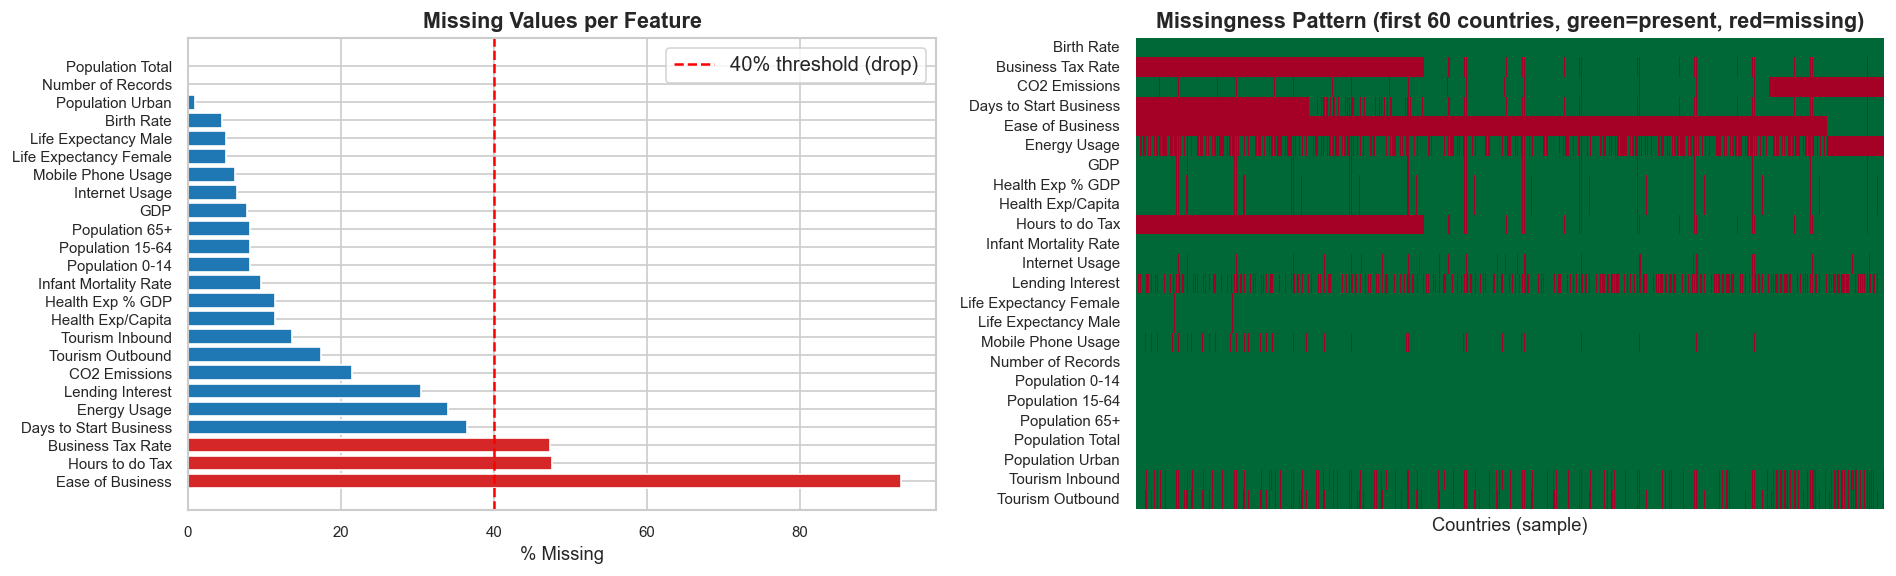


Missing Value Decision Table:


,null_count,null_pct,action
Ease of Business,2519,93.16,KEEP
Hours to do Tax,1288,47.63,KEEP
Business Tax Rate,1281,47.37,DROP (>40%)
Days to Start Business,986,36.46,KEEP
Energy Usage,919,33.99,KEEP
Lending Interest,824,30.47,KEEP
CO2 Emissions,579,21.41,DROP (>40%)
Tourism Outbound,471,17.42,KEEP
Tourism Inbound,368,13.61,DROP (constant)
Health Exp/Capita,309,11.43,KEEP


In [5]:
# ── Per-column missing value statistics ───────────────────────────────────────
num_df = df.select_dtypes(include='number')
miss   = num_df.isnull().mean().sort_values(ascending=False)
miss_pct = miss * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
ax = axes[0]
bars = ax.barh(miss_pct.index, miss_pct.values, color=['#d62728' if v > 40 else '#1f77b4' for v in miss_pct.values])
ax.axvline(x=40, color='red', linestyle='--', linewidth=1.5, label='40% threshold (drop)')
ax.set_xlabel('% Missing')
ax.set_title('Missing Values per Feature', fontweight='bold')
ax.legend()

# Heatmap of missingness pattern (sample)
ax2 = axes[1]
miss_matrix = num_df.isnull().astype(int)
# Sample 60 countries for readability
countries_sample = df[ID_COL].unique()[:60]
miss_sample = miss_matrix.loc[df[ID_COL].isin(countries_sample)]
sns.heatmap(miss_sample.T, ax=ax2, cmap='RdYlGn_r', cbar=False,
            xticklabels=False, yticklabels=True)
ax2.set_title('Missingness Pattern (first 60 countries, green=present, red=missing)', fontweight='bold')
ax2.set_xlabel('Countries (sample)')

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
miss_table = pd.DataFrame({
    'null_count' : num_df.isnull().sum(),
    'null_pct'   : miss_pct.round(2),
    'action'     : ['DROP (>40%)' if v > 40 else ('DROP (constant)' if col in DROP_COLS else 'KEEP')
                    for col, v in zip(miss_pct.index, miss_pct.values)]
}).sort_values('null_pct', ascending=False)

print('\nMissing Value Decision Table:')
display(miss_table[miss_table['null_count'] > 0])

In [6]:
# ── Columns flagged for dropping (config-level rules) ─────────────────────────
print('Columns dropped by rule:')
for col in DROP_COLS:
    if col in df.columns:
        pct = df[col].isnull().mean() * 100
        reason = f'{pct:.1f}% missing' if pct > 40 else 'constant / zero variance'
        print(f'  ✂  {col:<35} → {reason}')

high_miss_cols = miss_pct[miss_pct > HIGH_MISSING_COL_THRESHOLD * 100].index.tolist()
if high_miss_cols:
    print(f'\nAdditional columns above {HIGH_MISSING_COL_THRESHOLD*100:.0f}% threshold:')
    for c in high_miss_cols:
        print(f'  ✂  {c}')

Columns dropped by rule:
  ✂  Ease of Business                    → 93.2% missing
  ✂  Number of Records                   → constant / zero variance

Additional columns above 40% threshold:
  ✂  Ease of Business
  ✂  Hours to do Tax
  ✂  Business Tax Rate


---
## 5. Statistical Summary

In [7]:
# ── Assign year for panel-level stats ─────────────────────────────────────────
df['Year'] = df.groupby(ID_COL).cumcount() + 2000

# ── Extended descriptive stats ────────────────────────────────────────────────
desc = num_df.describe().T
desc['skewness'] = num_df.skew()
desc['kurtosis'] = num_df.kurt()
desc['cv_%']     = (num_df.std() / num_df.mean().abs() * 100).round(1)  # coefficient of variation
desc = desc.round(3)

print('Extended Statistical Summary (panel-level, 2,704 rows):')
display(desc[['count','mean','std','min','25%','50%','75%','max','skewness','kurtosis','cv_%']])

Extended Statistical Summary (panel-level, 2,704 rows):


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,cv_%
Birth Rate,2585.0,2.300000e-02,1.100000e-02,7.000000e-03,1.300000e-02,2.000000e-02,3.100000e-02,5.300000e-02,0.662,-0.684,49.9
Business Tax Rate,1423.0,4.896700e+01,4.095400e+01,8.200000e+00,3.240000e+01,4.100000e+01,5.155000e+01,3.391000e+02,4.343,21.827,83.6
CO2 Emissions,2125.0,1.423071e+05,6.159288e+05,7.000000e+00,1.360000e+03,8.529000e+03,5.910800e+04,8.286892e+06,8.654,83.081,432.8
Days to Start Business,1718.0,3.999900e+01,5.731900e+01,1.000000e+00,1.300000e+01,2.600000e+01,4.500000e+01,6.940000e+02,7.438,77.662,143.3
Ease of Business,185.0,9.487600e+01,5.479200e+01,1.000000e+00,4.800000e+01,9.400000e+01,1.420000e+02,1.890000e+02,0.018,-1.201,57.8
Energy Usage,1785.0,7.723684e+04,2.599239e+05,8.000000e+00,3.737000e+03,1.433800e+04,4.185200e+04,2.727728e+06,7.062,54.891,336.5
GDP,2494.0,2.638540e+11,1.129910e+12,6.310127e+07,3.539042e+09,1.507975e+10,1.102047e+11,1.624460e+13,9.424,105.533,428.2
Health Exp % GDP,2395.0,6.400000e-02,2.600000e-02,8.000000e-03,4.600000e-02,6.100000e-02,7.900000e-02,2.250000e-01,1.180,2.963,41.0
Health Exp/Capita,2395.0,8.013970e+02,1.473448e+03,2.000000e+00,5.000000e+01,1.930000e+02,6.650000e+02,9.908000e+03,2.817,8.399,183.9
Hours to do Tax,1416.0,3.020690e+02,2.733000e+02,1.200000e+01,1.560000e+02,2.390000e+02,3.447500e+02,2.600000e+03,4.491,30.792,90.5


In [8]:
# ── Highlight highly skewed features (candidates for log1p transform) ─────────
skewed = desc[desc['skewness'].abs() > 2]['skewness'].sort_values(ascending=False)
print('Highly skewed features (|skew| > 2) → log1p transform candidates:')
for col, sk in skewed.items():
    print(f'  {col:<35}  skewness = {sk:+.3f}')

Highly skewed features (|skew| > 2) → log1p transform candidates:
  Lending Interest                     skewness = +15.536
  GDP                                  skewness = +9.424
  Population Total                     skewness = +8.788
  CO2 Emissions                        skewness = +8.654
  Days to Start Business               skewness = +7.438
  Tourism Inbound                      skewness = +7.115
  Energy Usage                         skewness = +7.062
  Tourism Outbound                     skewness = +5.210
  Hours to do Tax                      skewness = +4.491
  Business Tax Rate                    skewness = +4.343
  Health Exp/Capita                    skewness = +2.817


---
## 6. Univariate Distributions

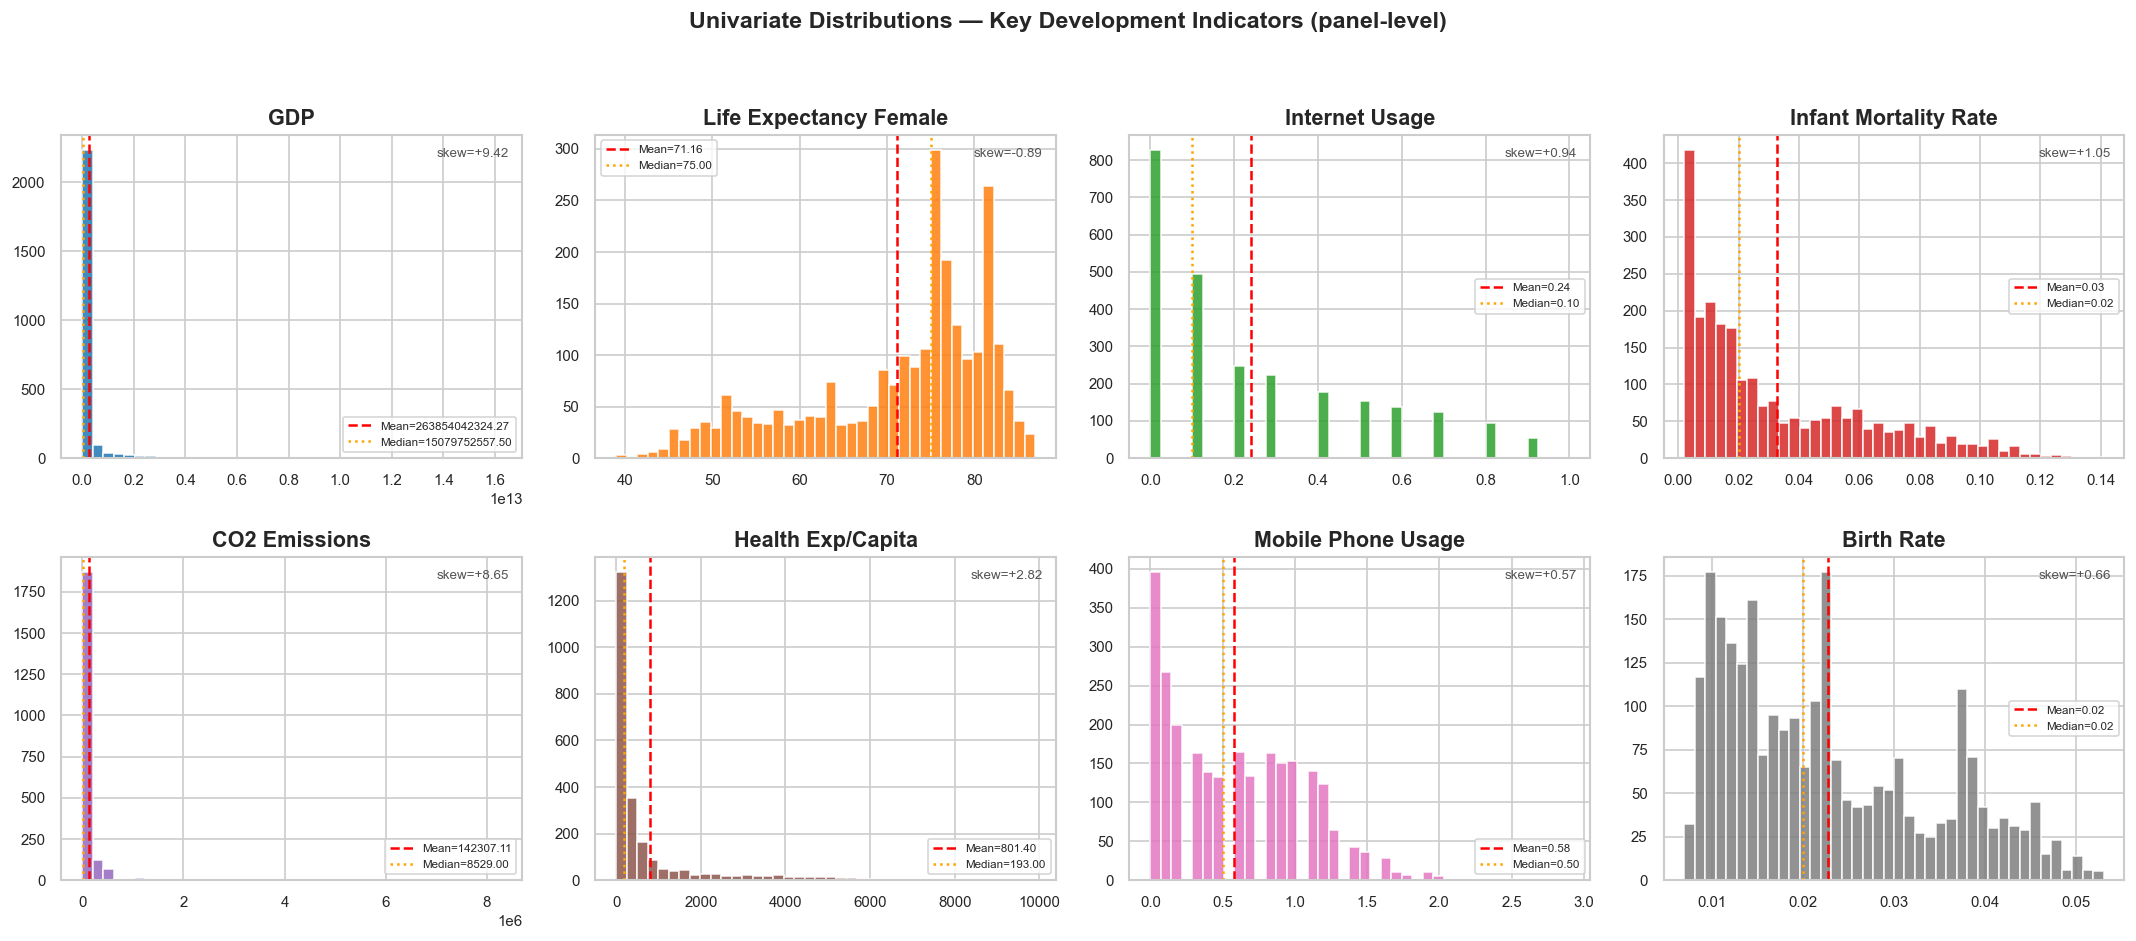

In [9]:
# ── Distribution grid for key development indicators ─────────────────────────
KEY_INDICATORS = [
    'GDP', 'Life Expectancy Female', 'Internet Usage', 'Infant Mortality Rate',
    'CO2 Emissions', 'Health Exp/Capita', 'Mobile Phone Usage', 'Birth Rate',
]
KEY_INDICATORS = [c for c in KEY_INDICATORS if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(KEY_INDICATORS):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=40, color=PALETTE[i % 10], edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='red',    linestyle='--', lw=1.5, label=f'Mean={data.mean():.2f}')
    ax.axvline(data.median(), color='orange', linestyle=':',  lw=1.5, label=f'Median={data.median():.2f}')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=7)
    skew_val = data.skew()
    ax.text(0.97, 0.93, f'skew={skew_val:+.2f}', transform=ax.transAxes,
            ha='right', fontsize=8, color='#555')

plt.suptitle('Univariate Distributions — Key Development Indicators (panel-level)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

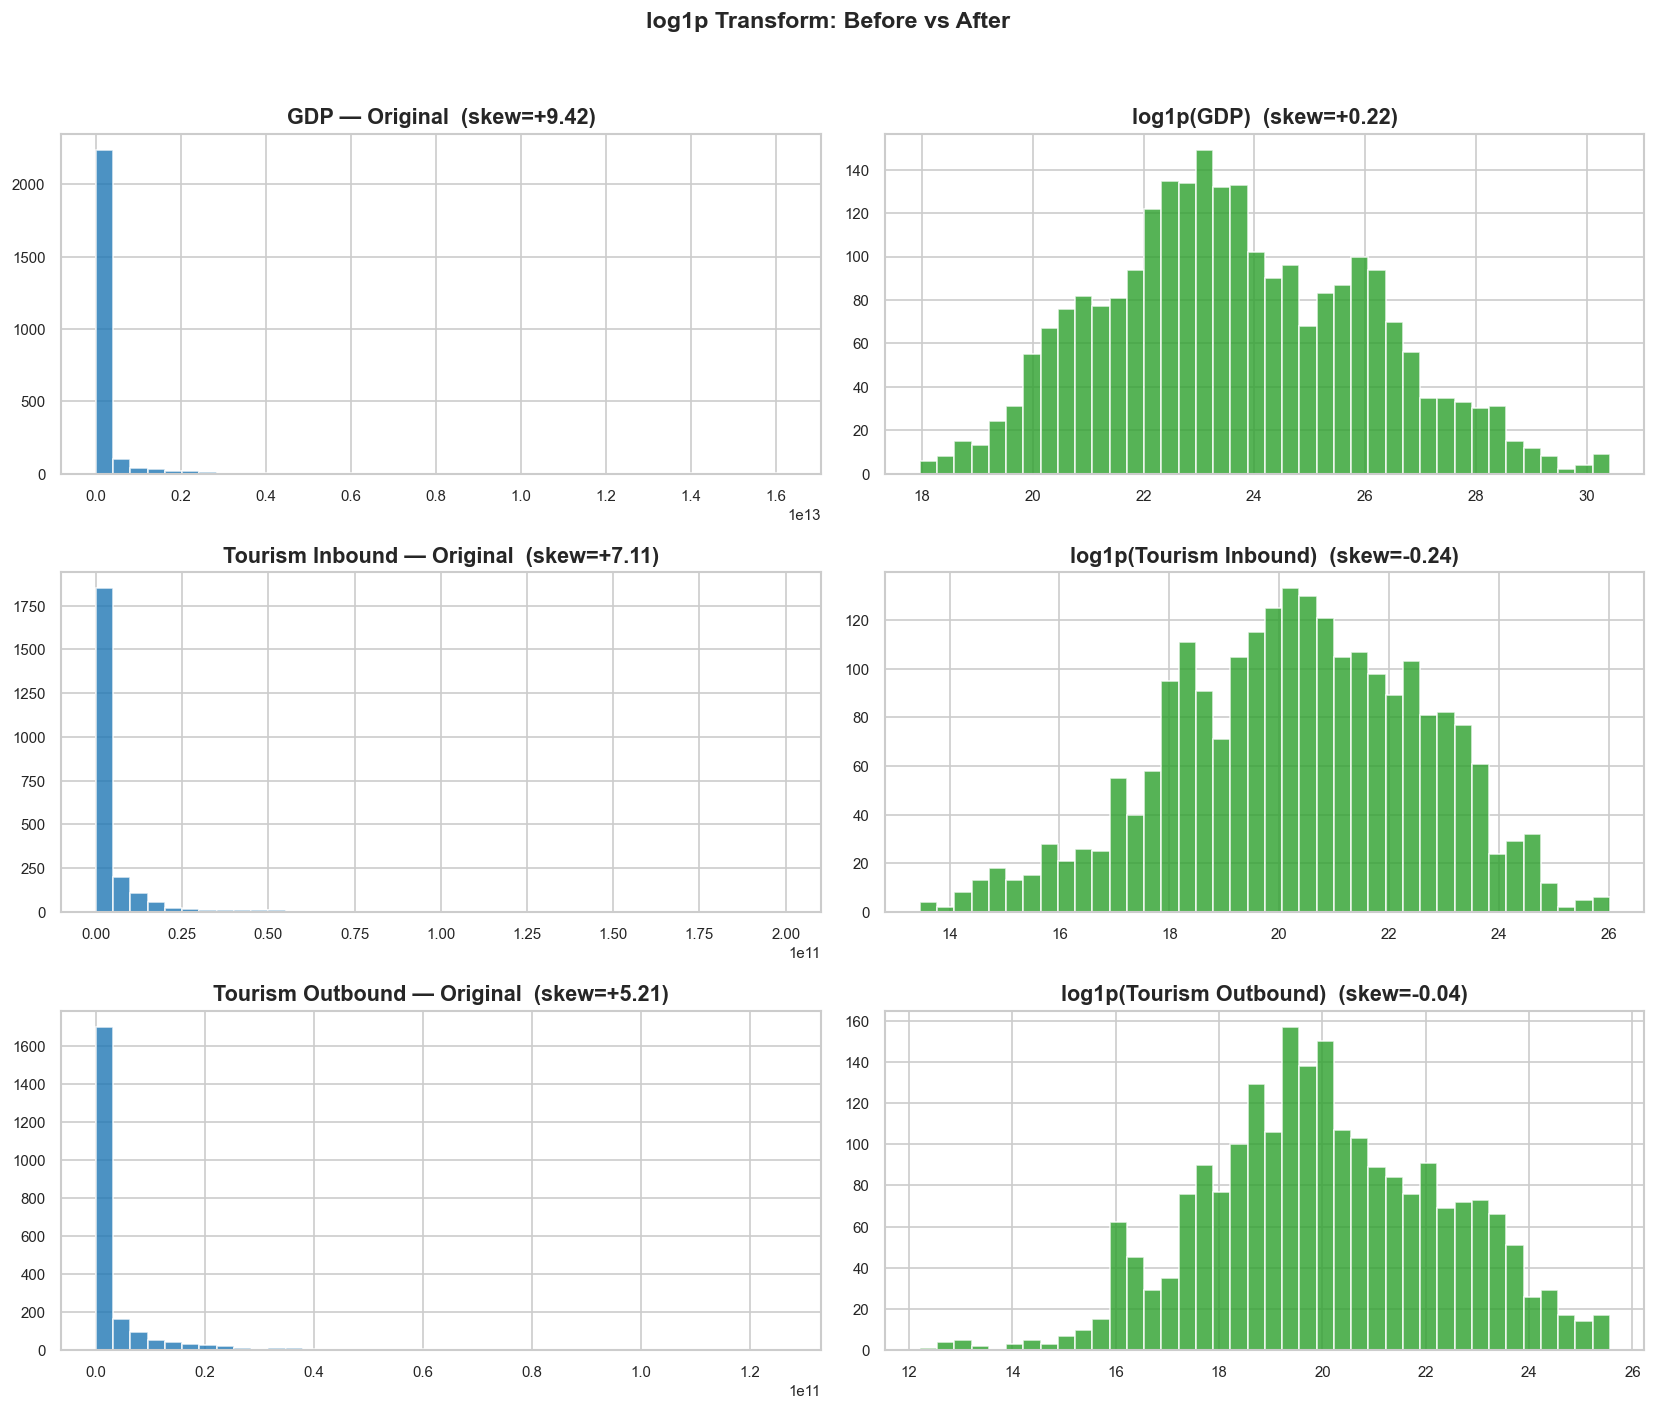

In [10]:
# ── Before/after log1p comparison for GDP ─────────────────────────────────────
LOG1P_SHOW = ['GDP', 'Tourism Inbound', 'Tourism Outbound']
LOG1P_SHOW = [c for c in LOG1P_SHOW if c in df.columns]

fig, axes = plt.subplots(len(LOG1P_SHOW), 2, figsize=(14, 4 * len(LOG1P_SHOW)))
if len(LOG1P_SHOW) == 1:
    axes = [axes]

for row, col in enumerate(LOG1P_SHOW):
    raw_data  = df[col].dropna().clip(lower=0)
    log_data  = np.log1p(raw_data)

    axes[row][0].hist(raw_data, bins=40, color='#1f77b4', edgecolor='white', alpha=0.8)
    axes[row][0].set_title(f'{col} — Original  (skew={raw_data.skew():+.2f})', fontweight='bold')

    axes[row][1].hist(log_data, bins=40, color='#2ca02c', edgecolor='white', alpha=0.8)
    axes[row][1].set_title(f'log1p({col})  (skew={log_data.skew():+.2f})', fontweight='bold')

plt.suptitle('log1p Transform: Before vs After', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

---
## 7. Correlation Analysis

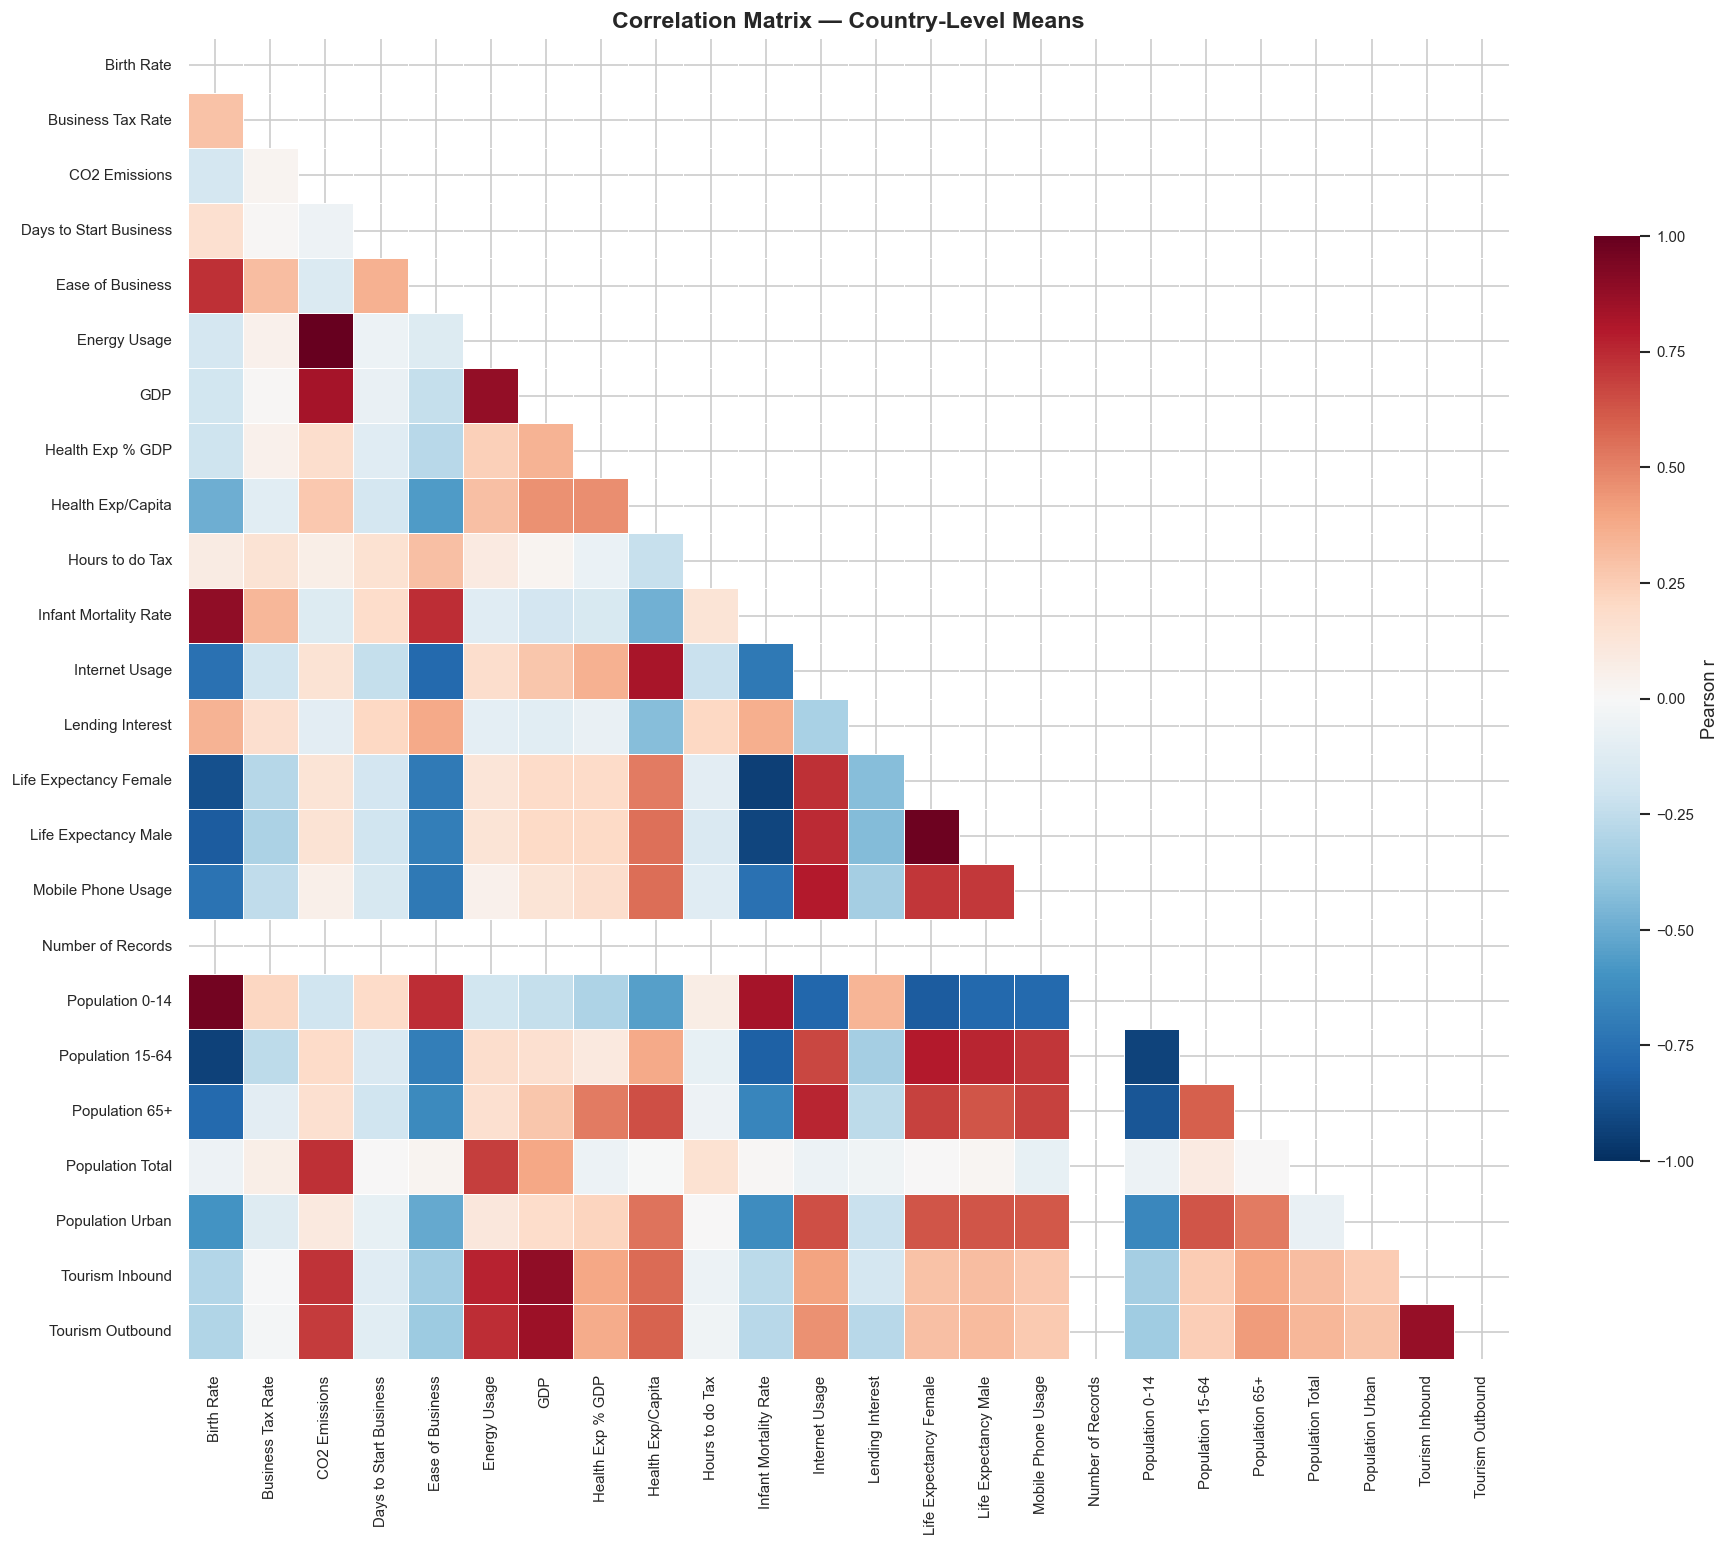

In [11]:
# ── Full correlation heatmap ──────────────────────────────────────────────────
num_agg = df.groupby(ID_COL)[num_df.columns].mean()  # country-level means for correlation
corr    = num_agg.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, annot=False, ax=ax,
            cbar_kws={'shrink': 0.7, 'label': 'Pearson r'})
ax.set_title('Correlation Matrix — Country-Level Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# ── High-correlation pairs (|r| > 0.90) → multicollinearity decisions ─────────
CORR_THRESHOLD = 0.90
upper = corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1))
high_corr_pairs = []

for col in upper.columns:
    for row in upper.index:
        val = upper.loc[row, col]
        if pd.notna(val) and abs(val) > CORR_THRESHOLD:
            high_corr_pairs.append({'feature_1': row, 'feature_2': col, 'pearson_r': round(val, 4)})

hc_df = pd.DataFrame(high_corr_pairs).sort_values('pearson_r', key=abs, ascending=False)
print(f'High-correlation pairs (|r| > {CORR_THRESHOLD}):')
display(hc_df)

print('\n→ These pairs drive the multicollinear drop in feature_engineering.py:')
from config.config import MULTICOLLINEAR_DROP, CORRELATION_DROP_THRESHOLD
print(f'  Pre-identified drops : {MULTICOLLINEAR_DROP}')
print(f'  Dynamic threshold    : |r| > {CORRELATION_DROP_THRESHOLD}')

High-correlation pairs (|r| > 0.9):


,feature_1,feature_2,pearson_r
0,CO2 Emissions,Energy Usage,0.9927
3,Life Expectancy Female,Life Expectancy Male,0.9784
4,Birth Rate,Population 0-14,0.9669
1,Infant Mortality Rate,Life Expectancy Female,-0.9388
5,Birth Rate,Population 15-64,-0.9313
6,Population 0-14,Population 15-64,-0.9275
2,Infant Mortality Rate,Life Expectancy Male,-0.9173



→ These pairs drive the multicollinear drop in feature_engineering.py:
  Pre-identified drops : ['Energy Usage', 'Life Expectancy Male', 'Population 15-64']
  Dynamic threshold    : |r| > 0.9


---
## 8. Temporal Trends (2000–2012)

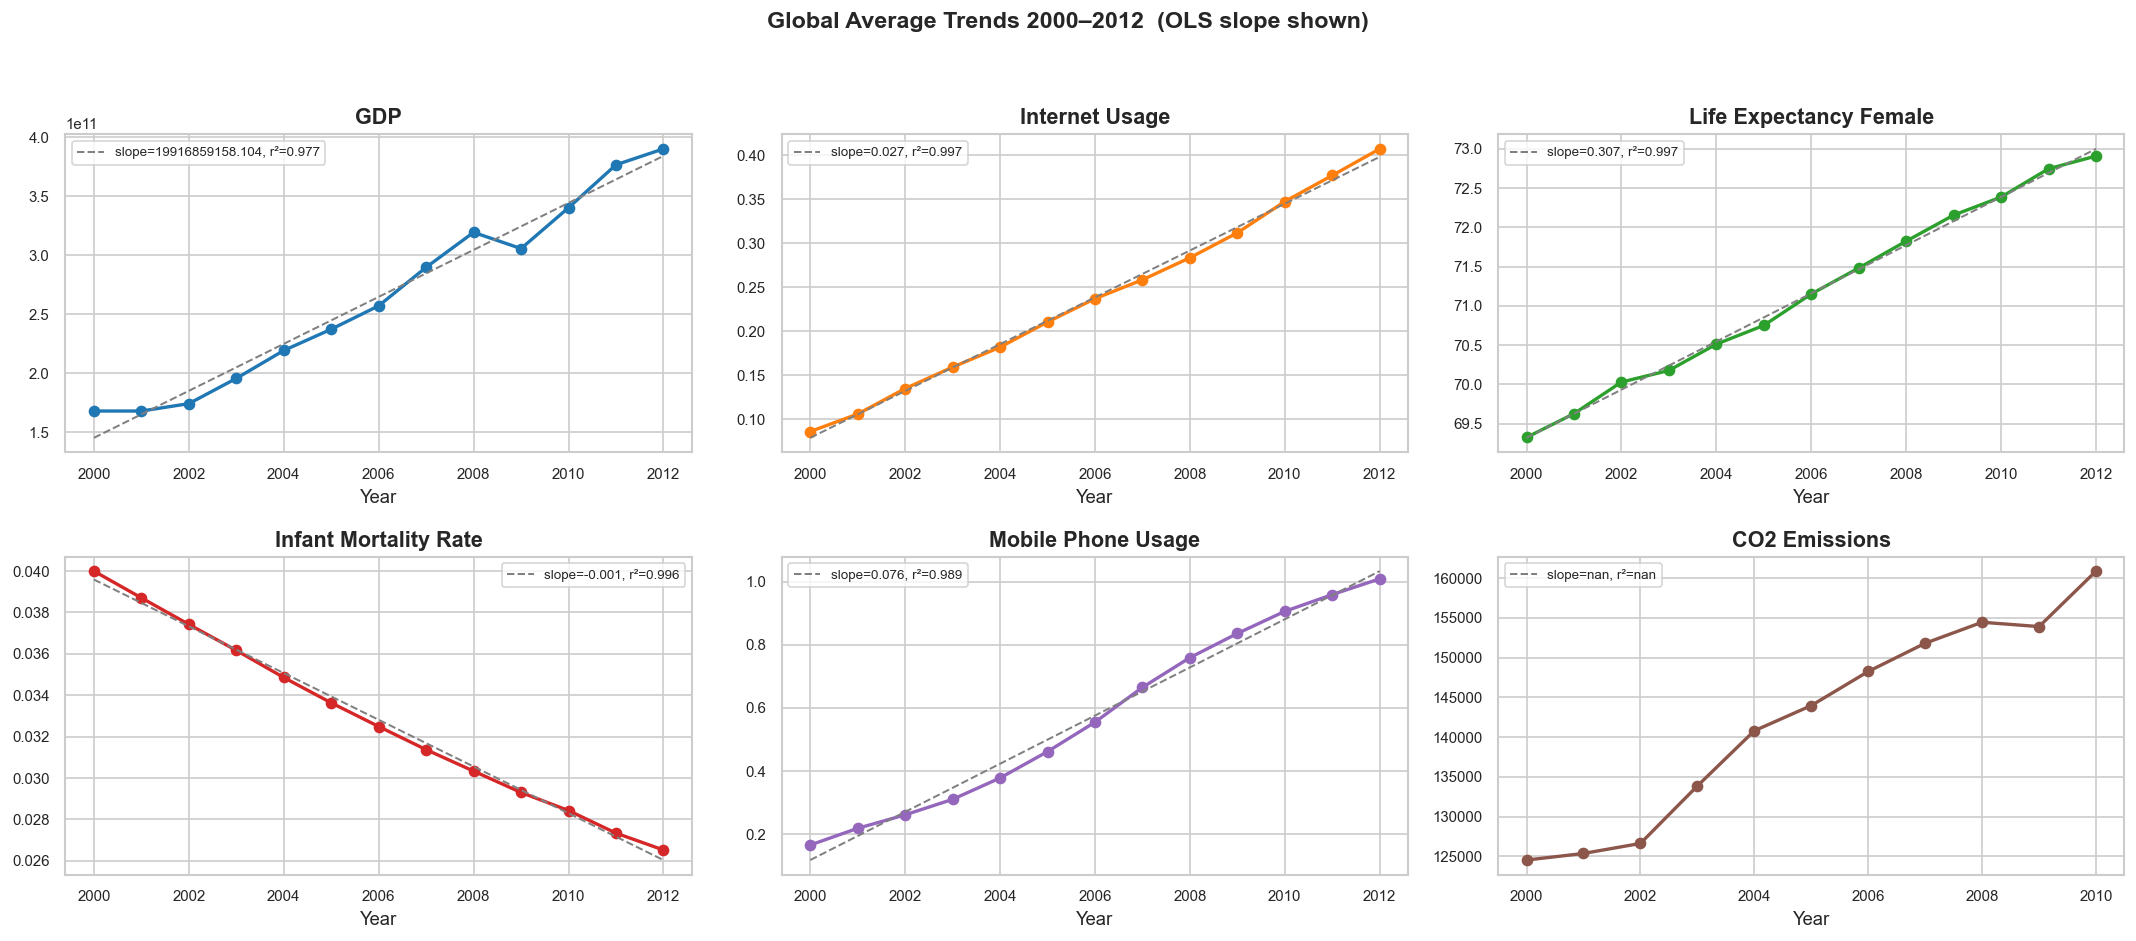

In [13]:
# ── Global average trends over time ──────────────────────────────────────────
TREND_SHOW = ['GDP', 'Internet Usage', 'Life Expectancy Female', 'Infant Mortality Rate',
              'Mobile Phone Usage', 'CO2 Emissions']
TREND_SHOW = [c for c in TREND_SHOW if c in df.columns]

yearly = df.groupby('Year')[TREND_SHOW].mean()

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(TREND_SHOW):
    ax = axes[i]
    ax.plot(yearly.index, yearly[col], 'o-', color=PALETTE[i % 10], lw=2)
    # OLS trendline
    slope, intercept, r, p, _ = stats.linregress(yearly.index, yearly[col])
    ax.plot(yearly.index, intercept + slope * yearly.index, '--', color='grey', lw=1.2,
            label=f'slope={slope:.3f}, r²={r**2:.3f}')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Year')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(2))

plt.suptitle('Global Average Trends 2000–2012  (OLS slope shown)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [14]:
# ── OLS trend-slope computation per country (mirrors data_ingestion.py) ───────
def compute_country_trend(grp, col):
    years = grp['Year'].values.astype(float)
    vals  = grp[col].values.astype(float)
    mask  = ~np.isnan(vals)
    if mask.sum() >= 3:
        slope, *_ = stats.linregress(years[mask], vals[mask])
        return round(float(slope), 6)
    return np.nan

trend_records = []
for country, grp in df.groupby(ID_COL):
    row = {ID_COL: country}
    for col in TREND_COLS:
        if col in df.columns:
            row[f'{col}_trend'] = compute_country_trend(grp, col)
    trend_records.append(row)

df_trends = pd.DataFrame(trend_records)
trend_feat_cols = [c for c in df_trends.columns if c != ID_COL]

print(f'Trend features computed: {len(trend_feat_cols)}')
print(f'Shape: {df_trends.shape}')
display(df_trends.describe().round(4))

Trend features computed: 5
Shape: (208, 6)


,GDP_trend,Internet Usage_trend,CO2 Emissions_trend,Life Expectancy Female_trend,Mobile Phone Usage_trend
count,1.950000e+02,199.0000,195.0000,199.0000,202.0000
mean,1.869503e+10,0.0265,4108.5391,0.3080,0.0763
std,6.133507e+10,0.0180,37691.1275,0.2330,0.0381
min,-4.162136e+08,0.0000,-20929.0091,-0.4615,-0.0300
25%,3.694345e+08,0.0110,2.7273,0.1813,0.0505
50%,1.581051e+09,0.0286,84.4545,0.2418,0.0742
75%,1.277945e+10,0.0407,647.8636,0.3626,0.0977
max,5.854042e+11,0.0789,517366.3545,1.4780,0.2088


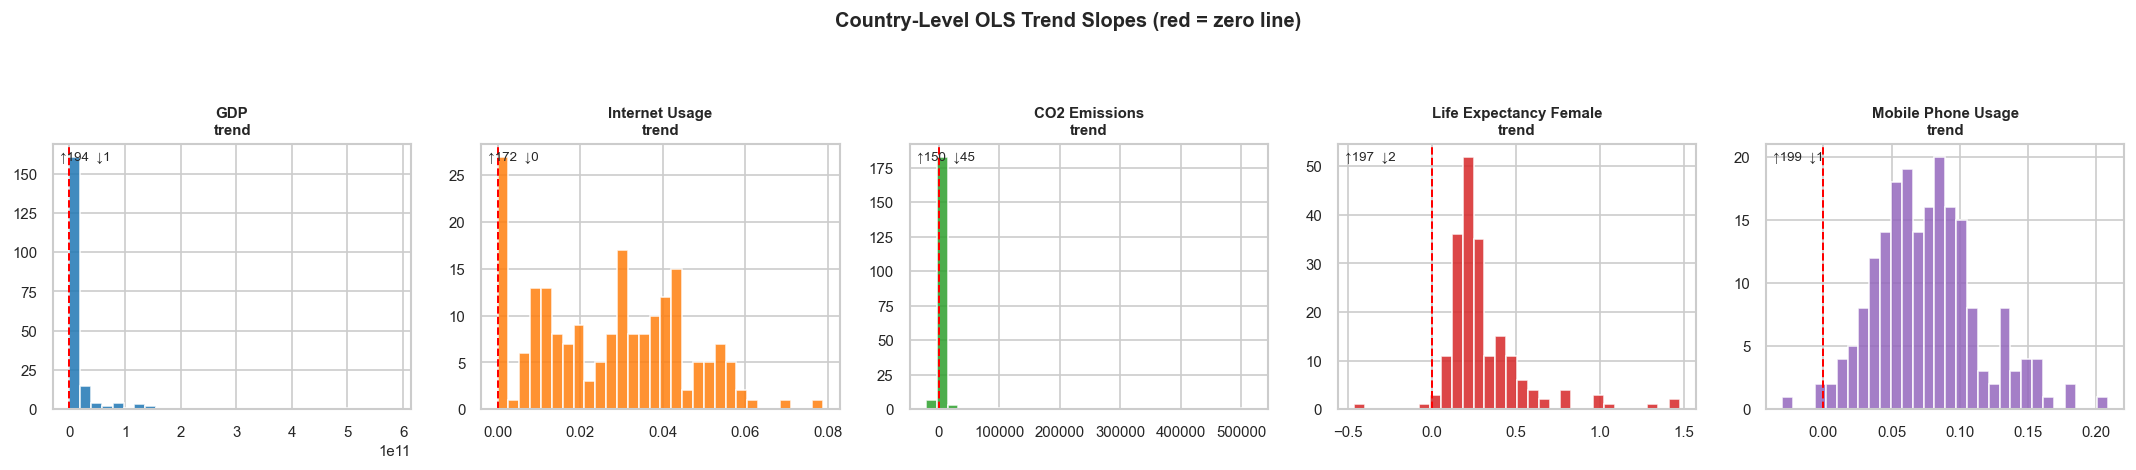


💡 Trend features are computed BEFORE country-level aggregation
   (Fix 1 in data_ingestion.py) to preserve temporal trajectory information.


In [15]:
# ── Trend distribution: who's growing vs declining? ───────────────────────────
fig, axes = plt.subplots(1, len(trend_feat_cols), figsize=(18, 4))
for i, col in enumerate(trend_feat_cols):
    data = df_trends[col].dropna()
    axes[i].hist(data, bins=30, color=PALETTE[i % 10], edgecolor='white', alpha=0.85)
    axes[i].axvline(0, color='red', linestyle='--', lw=1.2)
    n_pos = (data > 0).sum()
    n_neg = (data < 0).sum()
    axes[i].set_title(col.replace('_trend', '\ntrend'), fontweight='bold', fontsize=9)
    axes[i].text(0.02, 0.97, f'↑{n_pos}  ↓{n_neg}', transform=axes[i].transAxes,
                 va='top', fontsize=8)

plt.suptitle('Country-Level OLS Trend Slopes (red = zero line)', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

print('\n💡 Trend features are computed BEFORE country-level aggregation')
print('   (Fix 1 in data_ingestion.py) to preserve temporal trajectory information.')

---
## 9. Outlier Detection

In [16]:
# ── IQR-based outlier counts ──────────────────────────────────────────────────
IQR_MULT = 3.0  # matches config IQR_CAP_MULTIPLIER
num_agg_clean = df.groupby(ID_COL)[num_df.columns].mean()

outlier_report = []
for col in num_agg_clean.columns:
    series = num_agg_clean[col].dropna()
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    lo, hi = q1 - IQR_MULT * iqr, q3 + IQR_MULT * iqr
    n_low  = int((series < lo).sum())
    n_high = int((series > hi).sum())
    if n_low + n_high > 0:
        outlier_report.append({'feature': col, 'n_low': n_low, 'n_high': n_high,
                                'total_outliers': n_low + n_high, 'lower_bound': round(lo, 3),
                                'upper_bound': round(hi, 3)})

outlier_df = pd.DataFrame(outlier_report).sort_values('total_outliers', ascending=False)
print(f'Features with outliers (IQR×{IQR_MULT} rule), country-level:')
display(outlier_df)

Features with outliers (IQR×3.0 rule), country-level:


,feature,n_low,n_high,total_outliers,lower_bound,upper_bound
1,CO2 Emissions,0,23,23,-1.715010e+05,2.319373e+05
6,Health Exp/Capita,0,22,22,-1.655000e+03,2.329077e+03
11,Tourism Outbound,0,21,21,-7.899442e+09,1.078598e+10
3,Energy Usage,0,19,19,-8.345394e+04,1.167685e+05
4,GDP,0,17,17,-3.290577e+11,4.477833e+11
10,Tourism Inbound,0,16,16,-1.015365e+10,1.388455e+10
9,Population Total,0,15,15,-5.609822e+07,7.711041e+07
0,Business Tax Rate,0,7,7,-2.255000e+01,1.073000e+02
2,Days to Start Business,0,7,7,-5.960000e+01,1.203000e+02
7,Hours to do Tax,0,5,5,-4.040000e+02,9.023750e+02


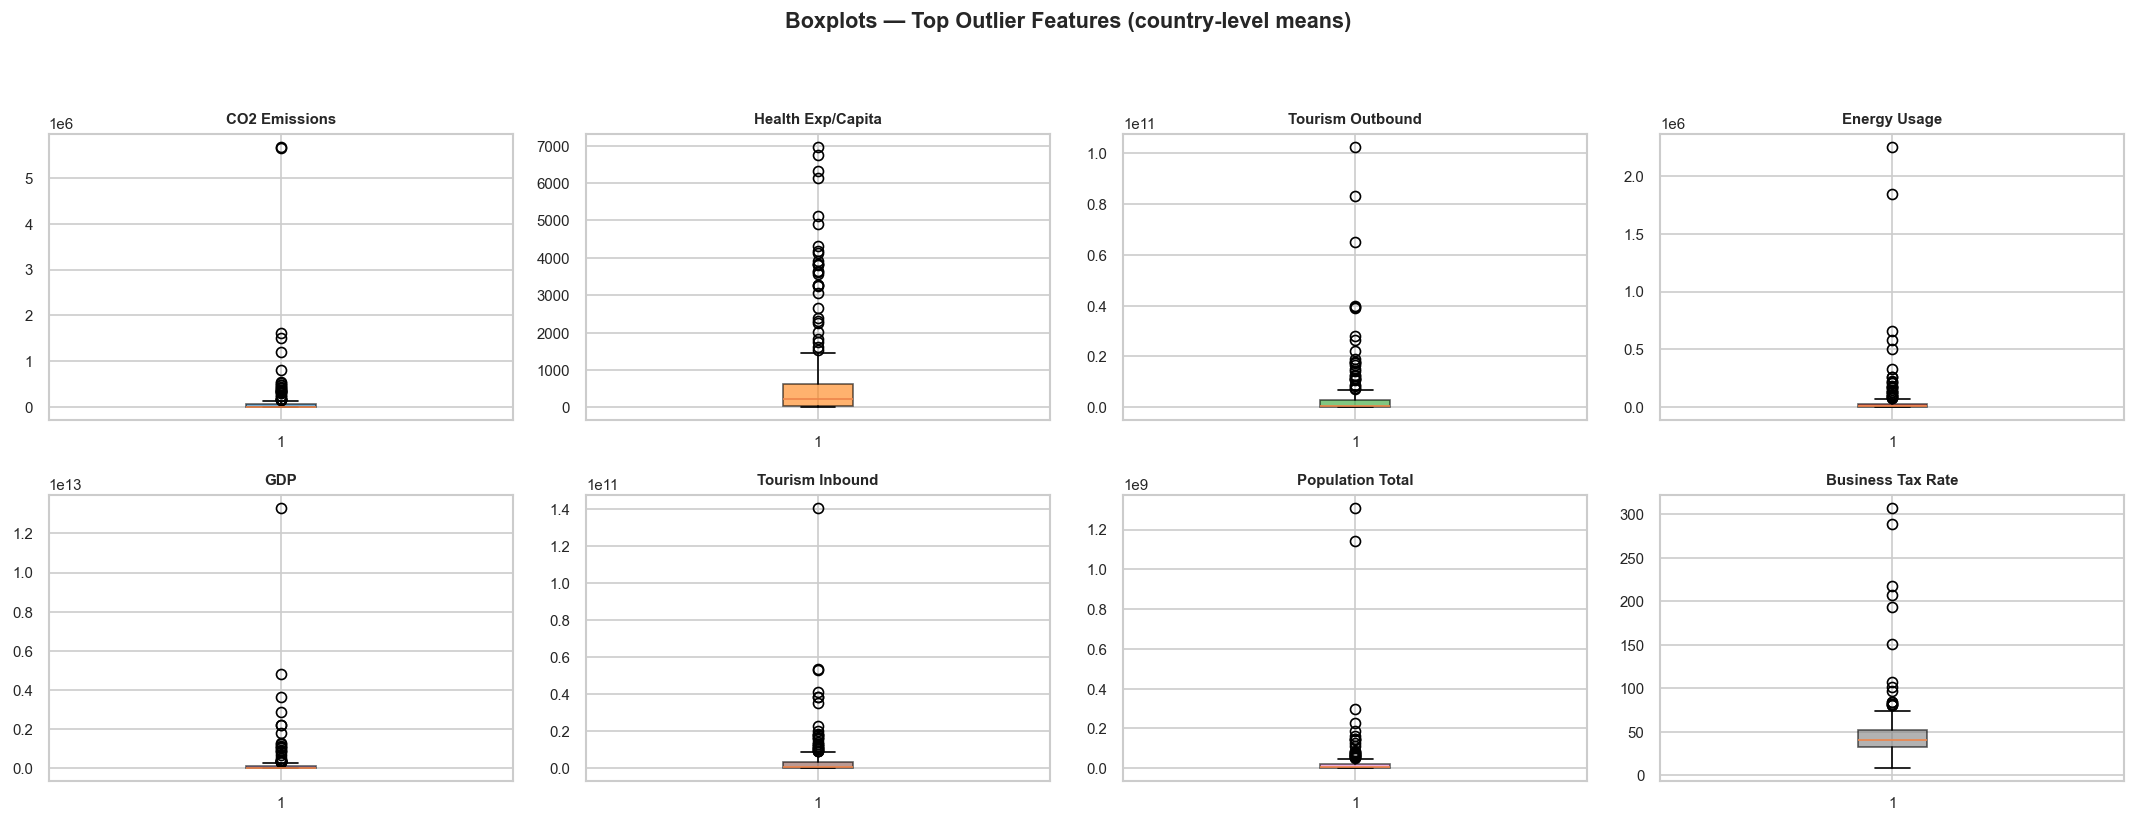

In [17]:
# ── Boxplot for top outlier features ─────────────────────────────────────────
top_outlier_cols = outlier_df.head(8)['feature'].tolist()
top_outlier_cols = [c for c in top_outlier_cols if c in num_agg_clean.columns]

if top_outlier_cols:
    fig, axes = plt.subplots(2, 4, figsize=(18, 7))
    axes = axes.flatten()
    for i, col in enumerate(top_outlier_cols):
        data = num_agg_clean[col].dropna()
        axes[i].boxplot(data, vert=True, patch_artist=True,
                        boxprops=dict(facecolor=PALETTE[i % 10], alpha=0.6))
        axes[i].set_title(col, fontweight='bold', fontsize=9)
    plt.suptitle('Boxplots — Top Outlier Features (country-level means)', fontsize=13, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()

---
## 10. EDA Conclusions

> Summary of design decisions derived from this EDA — each maps directly to a step in the pipeline.

In [18]:
conclusions = {
    'Finding'              : [
        '208 countries × 13 years (2000–2012)',
        'Ease of Business: 93%+ null',
        'Number of Records: constant = 1',
        'GDP, Tourism: extreme right skew (skew > 10)',
        'Energy Usage ↔ CO2 Emissions: r = 0.993',
        'Life Expectancy F ↔ M: r = 0.978',
        'Population bands: derived relationships',
        'Temporal trends: GDP ↑, Internet ↑, Infant Mortality ↓',
        'Outliers: Population Total, Tourism Inbound severe',
    ],
    'Pipeline Decision'    : [
        'Aggregate panel → cross-sectional (mean per country)',
        'DROP col at ingestion stage',
        'DROP col at ingestion stage',
        'Apply log1p before StandardScaler',
        'Drop Energy Usage (multicollinear_drop config)',
        'Drop Life Expectancy Male (multicollinear_drop config)',
        'Drop Population 15-64 (derived)',
        'Compute OLS slope BEFORE aggregation (Fix 1)',
        'IQR × 3.0 capping BEFORE imputation',
    ],
    'Pipeline File'        : [
        'data_ingestion.py',
        'data_ingestion.py',
        'data_ingestion.py',
        'data_preprocessing.py',
        'feature_engineering.py',
        'feature_engineering.py',
        'feature_engineering.py',
        'data_ingestion.py',
        'data_preprocessing.py',
    ],
}

conclusions_df = pd.DataFrame(conclusions)
print('EDA → Pipeline Decision Mapping:')
display(conclusions_df.style.set_properties(**{'text-align': 'left'}))

print('\n✅ EDA complete — proceed to Notebook 02: Preprocessing')

EDA → Pipeline Decision Mapping:


,Finding,Pipeline Decision,Pipeline File
0,208 countries × 13 years (2000–2012),Aggregate panel → cross-sectional (mean per country),data_ingestion.py
1,Ease of Business: 93%+ null,DROP col at ingestion stage,data_ingestion.py
2,Number of Records: constant = 1,DROP col at ingestion stage,data_ingestion.py
3,"GDP, Tourism: extreme right skew (skew > 10)",Apply log1p before StandardScaler,data_preprocessing.py
4,Energy Usage ↔ CO2 Emissions: r = 0.993,Drop Energy Usage (multicollinear_drop config),feature_engineering.py
5,Life Expectancy F ↔ M: r = 0.978,Drop Life Expectancy Male (multicollinear_drop config),feature_engineering.py
6,Population bands: derived relationships,Drop Population 15-64 (derived),feature_engineering.py
7,"Temporal trends: GDP ↑, Internet ↑, Infant Mortality ↓",Compute OLS slope BEFORE aggregation (Fix 1),data_ingestion.py
8,"Outliers: Population Total, Tourism Inbound severe",IQR × 3.0 capping BEFORE imputation,data_preprocessing.py



✅ EDA complete — proceed to Notebook 02: Preprocessing
